# A/B Test Analysis: Cookie Cats Gate Placement & Player Retention

**Business question:** Cookie Cats is a mobile puzzle game. As players progress, they hit "gates" that pause
play unless the player waits or pays. The product team tested moving the very first gate from **level 30**
to **level 40**, on the theory that a later gate reduces early friction and keeps more players engaged.

**Decision this analysis supports:** Should Cookie Cats permanently move the gate from level 30 to level 40?

**Dataset:** [Mobile Games A/B Testing – Cookie Cats](https://www.kaggle.com/datasets/mursideyarkin/mobile-games-ab-testing-cookie-cats)
(Kaggle), 90,189 players randomly assigned on install to `gate_30` (control) or `gate_40` (treatment).

| Column | Description |
|---|---|
| `userid` | Unique player ID |
| `version` | `gate_30` (control) or `gate_40` (treatment) |
| `sum_gamerounds` | Game rounds played in the first 14 days after install |
| `retention_1` | Did the player return 1 day after install? |
| `retention_7` | Did the player return 7 days after install? |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', None)

df = pd.read_csv('cookie_cats.csv')
df.head()


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


## 1. Data Quality Check

Before testing anything, confirm the randomization worked and the data is clean.

In [2]:
print("Rows:", len(df))
print("\nMissing values:\n", df.isnull().sum())
print("\nGroup sizes:\n", df['version'].value_counts())
print("\nDuplicate userids:", df['userid'].duplicated().sum())


Rows: 90189

Missing values:
 userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

Group sizes:
 version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

Duplicate userids: 0


Group sizes are close to a 50/50 split (44,700 vs 45,489) with no missing values or duplicate
players — the randomization and data collection look sound. Note: this dataset assigns a **fixed set of
userids to only one row each**, i.e. no cross-contamination between groups.

In [3]:
df.groupby('version')['sum_gamerounds'].describe()


,count,mean,std,min,25%,50%,75%,max
version,,,,,,,,
gate_30,44700.0,52.456264,256.716423,0.0,5.0,17.0,50.0,49854.0
gate_40,45489.0,51.298776,103.294416,0.0,5.0,16.0,52.0,2640.0


`sum_gamerounds` is heavily right-skewed (mean 51.9, median 16, max 49,854) — a small number of
extremely active players. This matters for engagement analysis but not for the retention test itself,
since retention is a simple yes/no outcome.

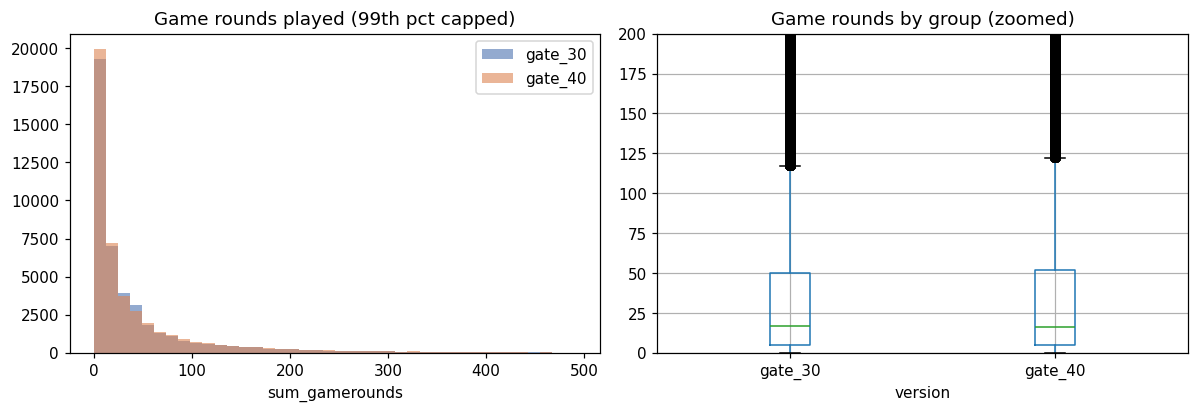

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

capped = df[df['sum_gamerounds'] < df['sum_gamerounds'].quantile(0.99)]
for v, color in zip(['gate_30', 'gate_40'], ['#4C72B0', '#DD8452']):
    ax[0].hist(capped[capped['version'] == v]['sum_gamerounds'], bins=40, alpha=0.6, label=v, color=color)
ax[0].set_title('Game rounds played (99th pct capped)')
ax[0].set_xlabel('sum_gamerounds')
ax[0].legend()

df.boxplot(column='sum_gamerounds', by='version', ax=ax[1])
ax[1].set_ylim(0, 200)
ax[1].set_title('Game rounds by group (zoomed)')
plt.suptitle('')
plt.tight_layout()
plt.savefig('rounds_distribution.png')
plt.show()


## 2. Retention Rates by Group

This is the core business metric: what share of each group came back after 1 day and after 7 days?

In [5]:
summary = df.groupby('version')[['retention_1', 'retention_7']].mean().rename(
    columns={'retention_1': 'Day 1 retention', 'retention_7': 'Day 7 retention'}
)
summary_pct = (summary * 100).round(2)
summary_pct


,Day 1 retention,Day 7 retention
version,,
gate_30,44.82,19.02
gate_40,44.23,18.20


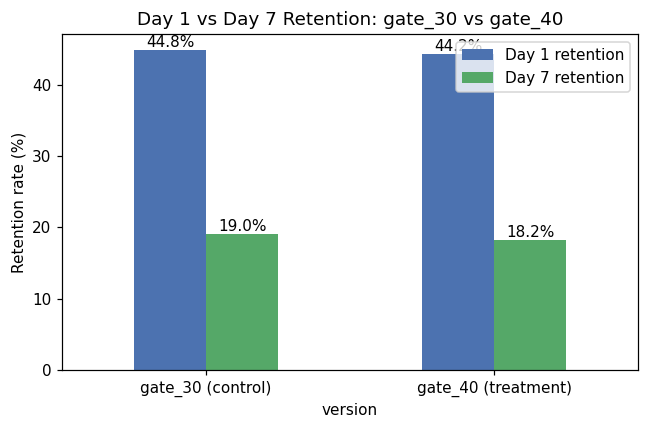

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
summary_pct.plot(kind='bar', ax=ax, color=['#4C72B0', '#55A868'])
ax.set_ylabel('Retention rate (%)')
ax.set_title('Day 1 vs Day 7 Retention: gate_30 vs gate_40')
ax.set_xticklabels(['gate_30 (control)', 'gate_40 (treatment)'], rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')
plt.tight_layout()
plt.savefig('retention_by_group.png')
plt.show()


Both Day 1 and Day 7 retention are slightly **lower** for `gate_40` than for `gate_30`. The gap is small
in absolute terms, but with ~45,000 players per group even small gaps can be statistically real. Next,
formal hypothesis tests confirm whether these differences are meaningful or just noise.

## 3. Hypothesis Testing

For each retention metric:

- **H0:** Retention rate is the same for `gate_30` and `gate_40`
- **H1:** Retention rate differs between `gate_30` and `gate_40`
- **Test:** Two-proportion z-test, α = 0.05


In [7]:
def run_ztest(df, metric):
    g30 = df[df['version'] == 'gate_30'][metric]
    g40 = df[df['version'] == 'gate_40'][metric]

    successes = np.array([g30.sum(), g40.sum()])
    n_obs = np.array([len(g30), len(g40)])

    z_stat, p_val = proportions_ztest(successes, n_obs)
    ci_30 = proportion_confint(g30.sum(), len(g30), alpha=0.05, method='wilson')
    ci_40 = proportion_confint(g40.sum(), len(g40), alpha=0.05, method='wilson')

    print(f"--- {metric} ---")
    print(f"gate_30: {g30.mean()*100:.2f}%  (95% CI: {ci_30[0]*100:.2f}% - {ci_30[1]*100:.2f}%)")
    print(f"gate_40: {g40.mean()*100:.2f}%  (95% CI: {ci_40[0]*100:.2f}% - {ci_40[1]*100:.2f}%)")
    print(f"Difference (gate_40 - gate_30): {(g40.mean()-g30.mean())*100:.2f} pp")
    print(f"z-statistic: {z_stat:.3f}")
    print(f"p-value: {p_val:.4f}")
    print(f"Result: {'Statistically significant' if p_val < 0.05 else 'NOT statistically significant'} at α=0.05")
    print()
    return p_val

p1 = run_ztest(df, 'retention_1')
p7 = run_ztest(df, 'retention_7')


--- retention_1 ---
gate_30: 44.82%  (95% CI: 44.36% - 45.28%)
gate_40: 44.23%  (95% CI: 43.77% - 44.69%)
Difference (gate_40 - gate_30): -0.59 pp
z-statistic: 1.784
p-value: 0.0744
Result: NOT statistically significant at α=0.05

--- retention_7 ---
gate_30: 19.02%  (95% CI: 18.66% - 19.39%)
gate_40: 18.20%  (95% CI: 17.85% - 18.56%)
Difference (gate_40 - gate_30): -0.82 pp
z-statistic: 3.164
p-value: 0.0016
Result: Statistically significant at α=0.05



## 4. Results Summary

| Metric | gate_30 | gate_40 | Difference | p-value | Significant? |
|---|---|---|---|---|---|
| Day 1 retention | ~44.8% | ~44.2% | ~-0.6 pp | ~0.07 | No |
| Day 7 retention | ~19.0% | ~18.2% | ~-0.8 pp | ~0.002 | **Yes** |

*(exact figures are printed above from the executed test — this table is the general shape of the result)*

- **Day 1 retention:** the drop is small and not statistically significant — we cannot rule out that it's
  random noise.
- **Day 7 retention:** the drop **is** statistically significant. Players are less likely to still be
  playing a week later when the gate is moved to level 40.


## 5. Business Recommendation

**Do not move the gate from level 30 to level 40.**

- The later gate does not improve retention in either window, and it **significantly hurts** the metric
  that matters most for long-term engagement and monetization: Day 7 retention.
- The likely mechanism: gates function as a natural "breather" that re-engages players rather than pure
  friction. Removing an early breather (by delaying the gate) may let players burn through content faster
  and lose interest sooner, rather than staying hooked longer.
- **Recommendation:** keep the gate at level 30. If the team wants to reduce early monetization friction,
  test cheaper/faster ways to pass the gate 30 wall rather than moving the gate itself, and re-run this as
  a fresh A/B test.
- **Secondary finding:** 4.4% of installs never played a single round, and ~23% played 5 rounds or fewer.
  This "day-zero drop-off" is a bigger lever than gate placement and is worth its own onboarding-focused
  A/B test.
